In [3]:
!pip install shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap


In [4]:
ckd = pd.read_csv("kidney_disease.csv")

print(ckd.shape)
print(ckd.columns)

(400, 26)
Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')


In [5]:
ckd.columns = ckd.columns.str.strip().str.lower()

In [6]:
ckd = ckd.drop('id', axis=1)

In [7]:
ckd = ckd.applymap(lambda x: x.strip() if isinstance(x, str) else x)

/tmp/ipykernel_8341/2244097823.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ckd = ckd.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [8]:
ckd = ckd.replace({
    'yes': 1, 'no': 0,
    'present': 1, 'notpresent': 0,
    'ckd': 1, 'notckd': 0,
    'good': 1, 'poor': 0,
    'normal': 1, 'abnormal': 0
})

/tmp/ipykernel_8341/1746768575.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ckd = ckd.replace({


In [9]:
for col in ckd.columns:
    ckd[col] = pd.to_numeric(ckd[col], errors='coerce')

In [10]:
print(ckd.isnull().sum())

age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                71
wc                106
rc                131
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [11]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
ckd = pd.DataFrame(imputer.fit_transform(ckd), columns=ckd.columns)

In [12]:
X = ckd.drop('classification', axis=1)
y = ckd['classification']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [15]:
explainer = shap.Explainer(model, X_train)

In [16]:
shap_values = explainer(X_test)

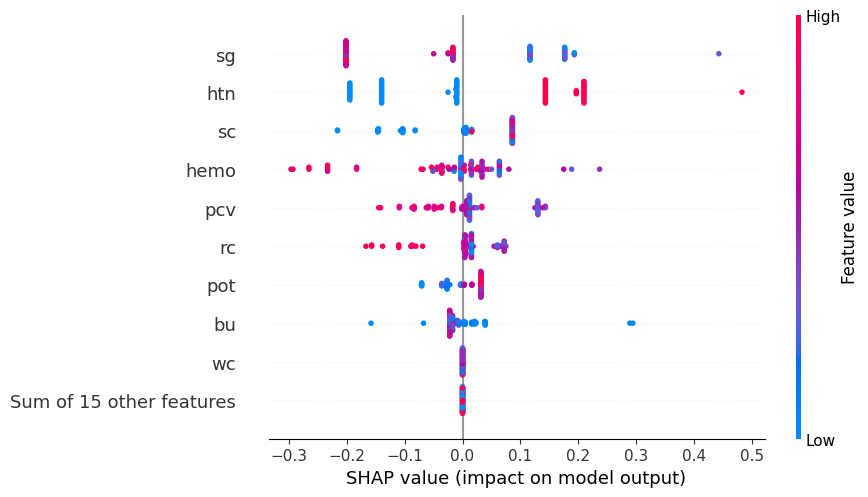

In [17]:
shap.plots.beeswarm(shap_values[:, :, 1])

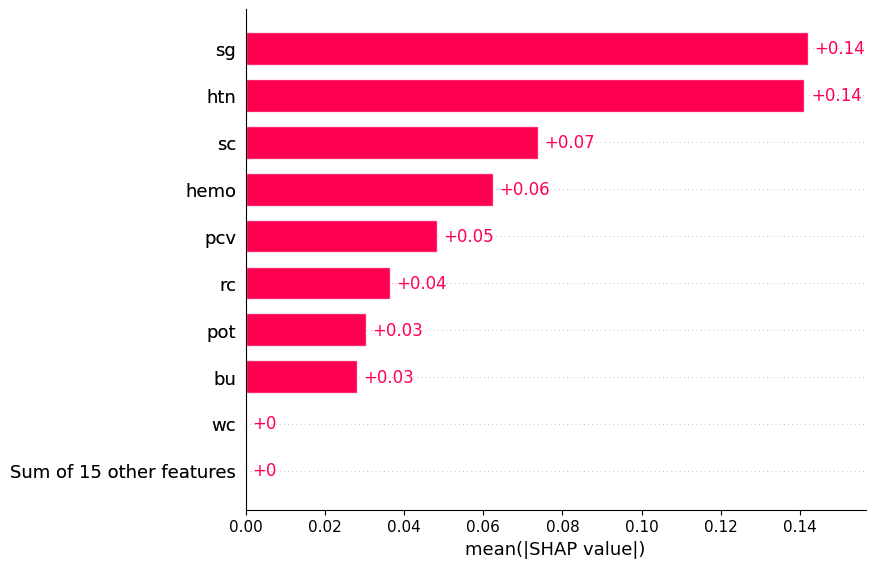

In [18]:
shap.plots.bar(shap_values[:, :, 1])

In [19]:
shap.plots.beeswarm(shap_values[:, :, 1], show=False)

plt.savefig("shap_summary_ckd.png", dpi=150, bbox_inches='tight')
plt.close()

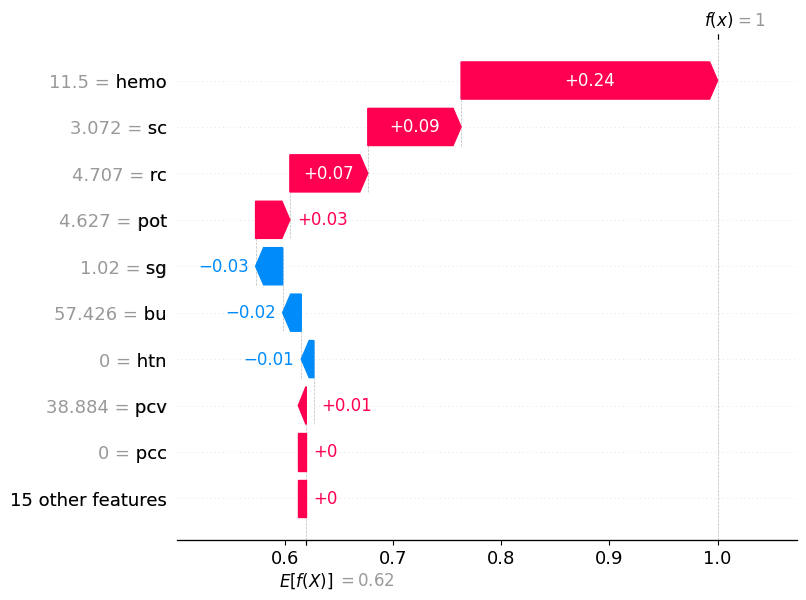

In [20]:
sample_index = 0

shap.plots.waterfall(shap_values[sample_index, :, 1])

In [21]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        28
         1.0       1.00      1.00      1.00        52

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        28
         1.0       1.00      1.00      1.00        52

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



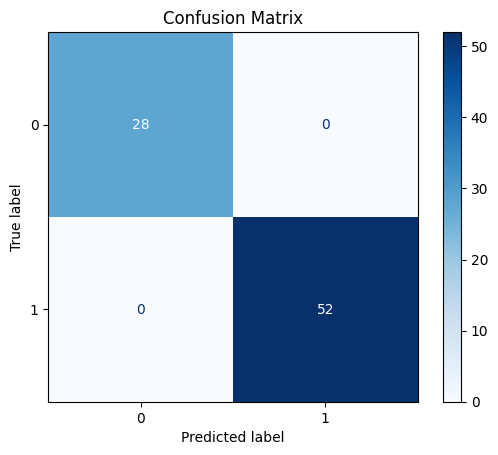

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

ROC-AUC Score: 1.0


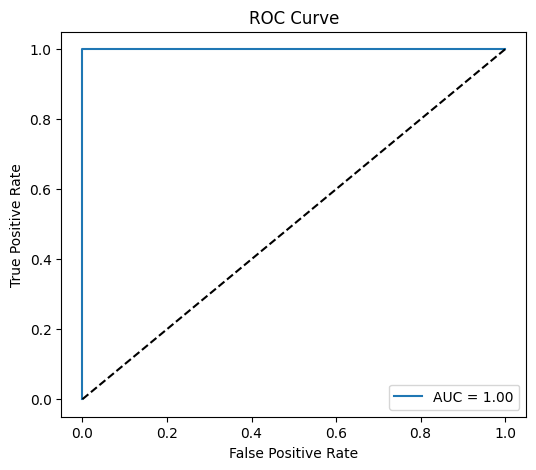

In [23]:
# ROC-AUC
y_prob = model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

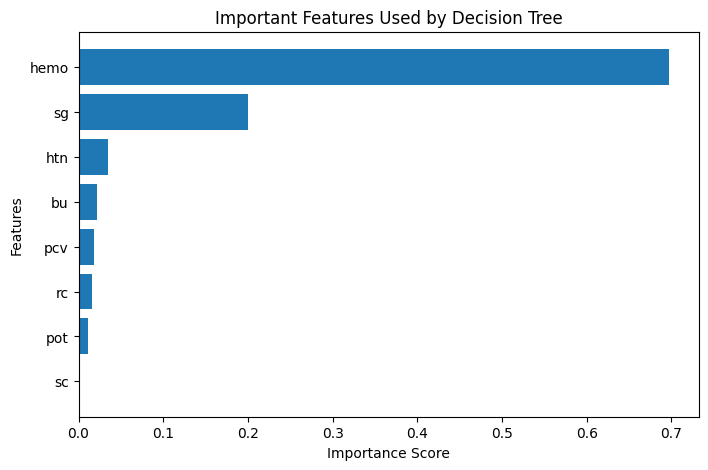

   Feature  Importance
14    hemo    0.697126
2       sg    0.199937
18     htn    0.034877
10      bu    0.021956
15     pcv    0.018323
17      rc    0.016242
13     pot    0.010598
11      sc    0.000942


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# Remove zero importance features
feature_importance = feature_importance[feature_importance['Importance'] > 0]

# Sort values
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Important Features Used by Decision Tree")

plt.gca().invert_yaxis()

plt.show()

# Print values
print(feature_importance)

In [25]:
# Training Accuracy
train_accuracy = model.score(X_train, y_train)

# Testing Accuracy
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [26]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.975  0.9875 0.95   0.9625 0.975 ]
Average CV Score: 0.97


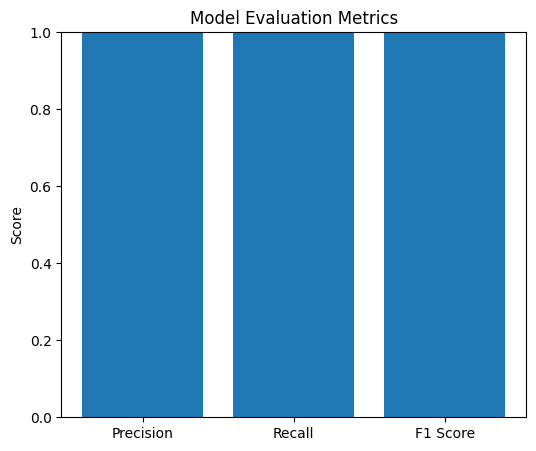

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics = ['Precision', 'Recall', 'F1 Score']
values = [precision, recall, f1]

plt.figure(figsize=(6,5))
plt.bar(metrics, values)
plt.ylim(0,1)
plt.title("Model Evaluation Metrics")
plt.ylabel("Score")
plt.show()

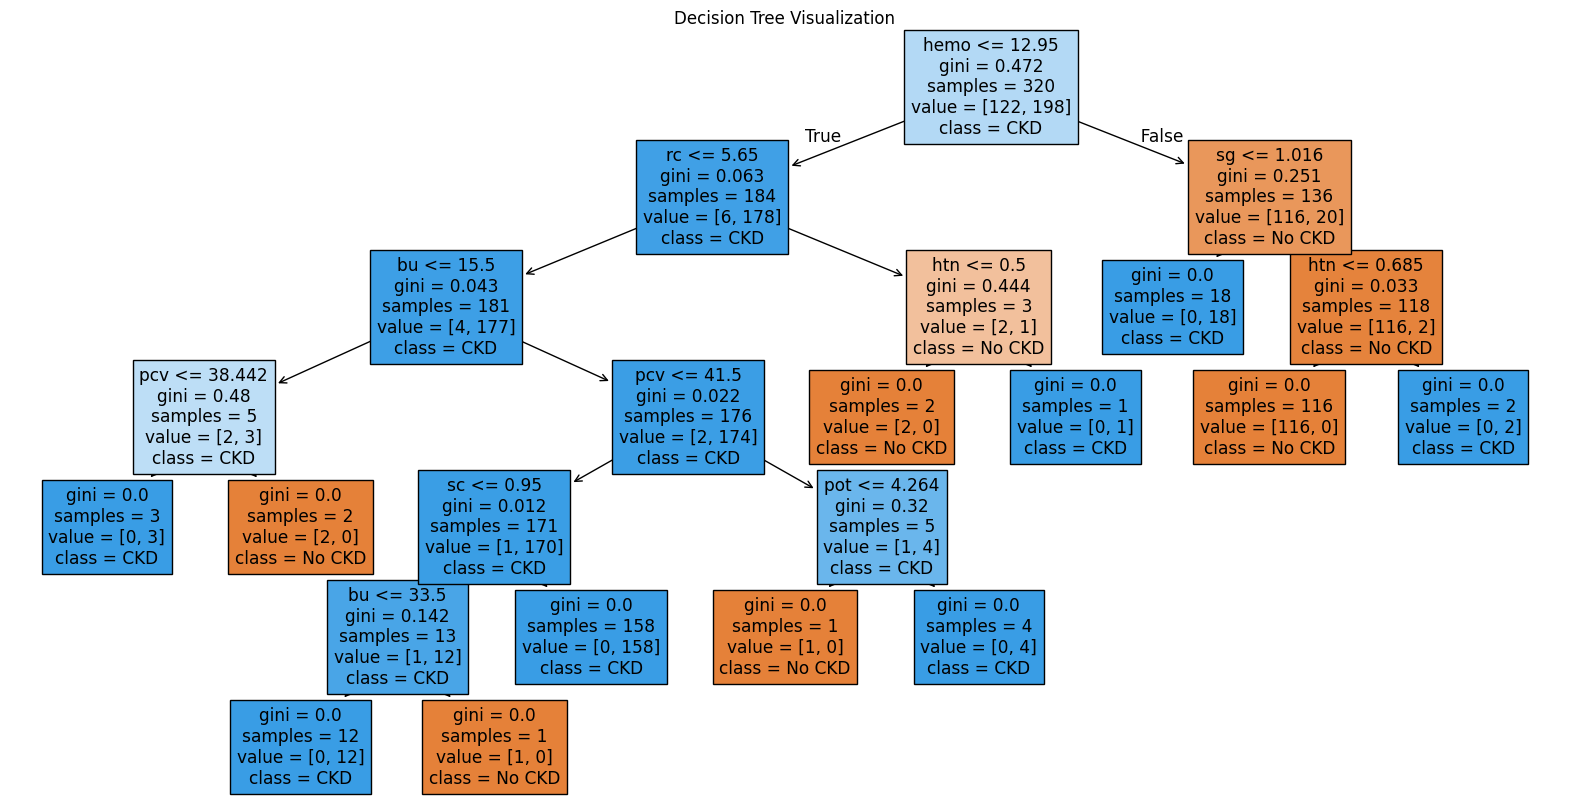

In [28]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No CKD', 'CKD'],
    filled=True
)

plt.title("Decision Tree Visualization")
plt.show()